# K-Means In Real Life: Clustering Habits of Positive Mood

## Introduction

K-Means is an unsupervised method for identifying clusters within data sets, where K represents the number of clusters to be created.    This method is helpful when you do not clearly understand the similarities of records in the data.  By applying K-Means, these clusters can be identified and further researched. 

## Literature Review

In her article, Carolina Bento uses a data set related to workouts to explain how K-Means clusters can be identified as helpful.  Using the workouts data set, Bento attempts to answer the question, “Which workouts are most similar?” (Bento, 2018).  In his article, Zach Bobbitt walks through performing K-means clustering in Python using data from basketball players' stats (Bobbitt, 2022).  Bobbitt clusters groups of players with similar points, assists, and rebound statistics in the player's data set.  Both articles demonstrate the value of using K-means analysis on data sets to form similar data clusters.

## Research

### Clustering Habits of Positive Daily Sentiment

Many people will have different habits and experiences in a given day.  For example, the time a person wakes in the morning, the amount of sleep they got the night before, general health conditions, food or water intake, exercise levels, and other factors could influence the person’s sentiment of the day.  We could use K-means analysis to understand the clusters of habits that result in a person having a more positive sentiment of their day.  Given sufficient data, this analysis could further delineate between habits that align with positive mood by race and gender and other factors (e.g., chronic health conditions, occupation, age, etc).  In the experiment, we could ask users to track habits that impact mood and submit these data daily.  Alternatively, we could leverage data the user shares via various providers (e.g., Apple et al.).  As a starting point, we should define a set of habits that users can track, allowing us to analyze a consistent set of habits.  In addition, we could allow users to create new habits to be tracked.  Throughout the analysis, we must ensure sufficient data for each habit and its relationship to the user's daily sentiment.

### Sample Dataset and Analysis

To better understand K-means implementation using Python, I created a sample data set and used the libraries specified in Bobbit’s article to analyze the data.  In Table 1 (see Appendix: Codebook), we can see a subset of sample habits collected by a research participant.

Through analysis of the data using pair plots in Seaborn, I determined that the habits “Number of Meetings,” “Duration of Sleep Prior Night (hours),” and “Duration of Exercise (minutes)” correlate with the daily sentiment of this participant.  Initial analysis of the data shown in Figure 1 (See Appendix: Codebook) demonstrates that a good K value for this data set is 3.

Figure 2 (See Appendix: Codebook) shows the relationship between the habits and sentiments and the 3 clusters formed by K-means analysis.  Because K-means analysis in Python requires numeric values, we have factionalized the PerceivedEndOfDayMood variable where Bad is represented by the number zero and Good is represented by one. Neutral is represented by the number two.  From the analysis, we see that cluster zero data contains days where the user has had a good night's sleep, sufficient exercise, and a low number of meetings for the day.  A high number of meetings and low levels of sleep and exercise form cluster two.  

## Conclusion

Using unsupervised methods, k-means analysis provides a way to identify similar groups within a data set.  This analysis assists with forming clusters that can be further explored to answer research questions.  In our research example, we demonstrate that with a set of habit-tracking data, we can identify similarities in groups that lead to positive sentiment about a person’s day.  By expanding the population of participants and trackable habits, we could find correlations in habits that lead to generally positive sentiments.

## Appendix: References
* Bento, C. (2018, December 3). K-Means in real life: Clustering workout sessions - towards data science. Medium. Accessed 04/20/2024. https://towardsdatascience.com/k-means-in-real-life-clustering-workout-sessions-119946f9e8dd 
* Cheng, J. (2021, December 6). Data Exploration and Visualization with Seaborn Pair Plots. Medium. Accessed 04/20/2024. https://medium.com/@jaimejcheng/data-exploration-and-visualization-with-seaborn-pair-plots-40e6d3450f6d 
* Bobbitt, Z. (2022, August 31). K-Means Clustering in Python: Step-by-Step Example. Statology. Accessed 4/20/2024. https://www.statology.org/k-means-clustering-in-python/ 

## Appendix: Code Book

In [1]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt 
from sklearn.cluster import KMeans 
from sklearn.preprocessing import StandardScaler 

### Load and review the dataset

In [2]:
# Create Dataframe
df = pd.read_csv('../data/habits_mood.csv')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33 entries, 0 to 32
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Date                     33 non-null     object 
 1   DaysBetweenTracking      33 non-null     int64  
 2   WaterInakeMl             33 non-null     int64  
 3   ExerciseDuration         33 non-null     int64  
 4   PrimaryTypeOfExercise    33 non-null     object 
 5   SleepDurationPriorNight  33 non-null     int64  
 6   NumberOfMeetings         33 non-null     int64  
 7   DurationOfMeetings       33 non-null     int64  
 8   UnplannedWorkInjected    33 non-null     float64
 9   MinutesSpentOnBreak      33 non-null     int64  
 10  PerceivedEndOfDayMood    33 non-null     object 
dtypes: float64(1), int64(7), object(3)
memory usage: 3.0+ KB


In [ ]:
print("Table 1: Sample Data from habits_mood.csv")
df.sample(5, random_state=42)

Table 1: Sample Data from habits_mood.csv


,Date,ExerciseDuration,SleepDurationPriorNight,NumberOfMeetings,PerceivedEndOfDayMood,cluster
31,1578528000,40,4,3,0,1
15,1575936000,45,6,3,0,1
26,1577664000,60,8,2,1,0
17,1576281600,40,5,2,0,1
8,1575158400,35,7,4,2,0


### Feature Engineering

In [5]:
df['PrimaryTypeOfExercise'] = pd.factorize(df['PrimaryTypeOfExercise'])[0]

In [6]:
df['PerceivedEndOfDayMood'] = df['PerceivedEndOfDayMood'].map({'GOOD': 1, 'POOR': 0, 'NEUTRAL': 2})

In [7]:
df['Date'] = pd.to_datetime(df['Date'])
df['Date'] = df['Date'].values.astype(np.int64) // 10**9

### Limit features for clustering

In [8]:
df = df[['Date','ExerciseDuration','SleepDurationPriorNight','NumberOfMeetings','PerceivedEndOfDayMood']]

### Drop rows with NA values

In [9]:
# drop rows with NA values in any columns
df = df.dropna()

### Scale the dataframe

In [10]:
# create scaled Dataframe where each variable has mean of 0 and standard deviation of 1
scaled_df = StandardScaler().fit_transform(df)

In [11]:
# view first five rows of scaled dataframe
print(scaled_df[:5])

[[-1.62437506 -1.75030306 -1.30403763  2.53533744 -0.8977584 ]
 [-1.56218901 -1.31601734 -0.6209703   1.55102996 -0.8977584 ]
 [-1.50000296 -0.01316017  0.74516436 -0.90973873  0.748132  ]
 [-1.37563085 -1.31601734 -0.6209703   1.05887623 -0.8977584 ]
 [-1.3134448  -0.01316017  0.06209703 -0.41758499 -0.8977584 ]]


### Identify Number of Clusters to create

In [12]:
# initialize kmeans parameter
kmeans_kwargs = {
    "init": "random",
    "n_init": 10,
    "random_state": 1,
}

In [13]:
# create list to hold SSE values for each K
# SSE = Sum of Squared Errors
sse = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, **kmeans_kwargs)
    kmeans.fit(scaled_df)
    sse.append(kmeans.inertia_)

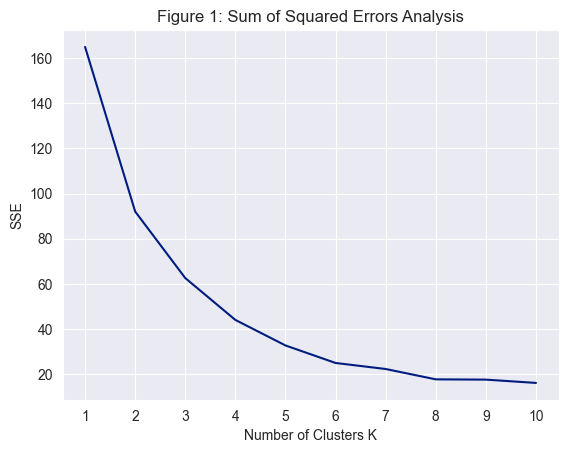

In [20]:
# visualize results
plt.plot(range(1, 11), sse)
plt.title("Figure 1: Sum of Squared Errors Analysis")
plt.xticks(range(1, 11))
plt.xlabel("Number of Clusters K")
plt.ylabel("SSE")
plt.show()

### Instantiate K-Means Clusters

In [15]:
# instantiated the k-means class, using optimal number of clusters
kmeans = KMeans(init="random", n_clusters=3, n_init=11, random_state=1)

In [16]:
# fit k-means algorithm to data
kmeans.fit(scaled_df)

,n_clusters,3
,init,'random'
,n_init,11
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,1
,copy_x,True
,algorithm,'lloyd'


In [17]:
# view cluster assignments for each observation
df['cluster'] = kmeans.labels_

In [18]:
display(df)

,Date,ExerciseDuration,SleepDurationPriorNight,NumberOfMeetings,PerceivedEndOfDayMood,cluster
0,1573948800,25,5,8,0,2
1,1574035200,30,6,6,0,2
2,1574121600,45,8,1,1,0
3,1574294400,30,6,5,0,2
4,1574380800,45,7,2,0,1
5,1574640000,25,5,6,0,2
6,1574726400,35,7,5,2,0
7,1575072000,25,5,5,0,2
8,1575158400,35,7,4,2,0
9,1575244800,45,8,1,1,0


### Visualize K-Means Clusters

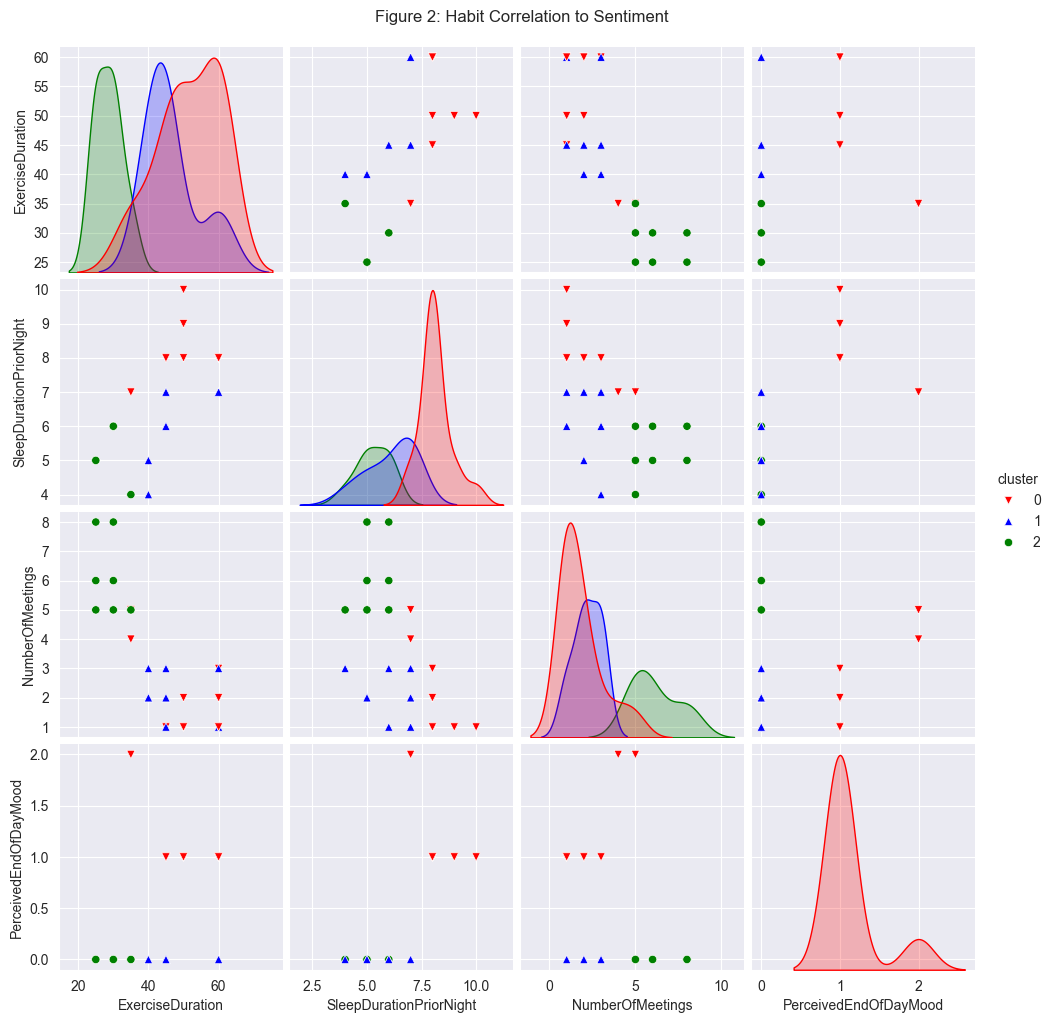

In [27]:
# visualize pair plot
sns.set_style("darkgrid")
sns.set_palette("dark")
sns.pairplot(df, 
             hue='cluster', 
             markers=['v','^','o'],
             palette = ['red','blue','green'], 
             vars=['ExerciseDuration',
                   'SleepDurationPriorNight',
                   'NumberOfMeetings',
                   'PerceivedEndOfDayMood']).fig.suptitle("Figure 2: Habit Correlation to Sentiment", y=1.02)
plt.show()